In [1]:

!pip install google-generativeai pillow langchain-chroma

In [23]:
import ollama
def ask_llm(prompt):
    response = ollama.chat(
        model = "llama3:8b",
        messages = [{
            "role" : "user",
            "content" : prompt
        }],
        stream = true
    )
    for res in response:
        print(res['messages']['content'],end="",flush = True)

In [24]:
import requests

def generate_response(prompt):

    response = requests.post(
        "https://text-generation.kuchana-akshitha.workers.dev/",
        headers={
            "Authorization": "Bearer 12345678",
            "Content-Type": "application/json"
        },
        json={
            "prompt": prompt
        }
    )
    data = response.json()
    print(data['response'])
    return data['response']

In [25]:
from docling.document_converter import (
    DocumentConverter,
    PdfFormatOption
)

from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions

# Configure PDF processing
pipeline_options = PdfPipelineOptions()

# Extract images
pipeline_options.generate_picture_images = True
pipeline_options.generate_page_images = True

# Create converter
converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=pipeline_options
        )
    }
)

result = converter.convert(
    r"D:\Downloads\AI_Report.pdf"
)

doc = result.document

The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.
[INFO] 2026-06-15 18:59:04,430 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-15 18:59:04,519 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-15 18:59:04,520 [RapidOCR] main.py:65: Using C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-06-15 18:59:04,836 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-06-15 18:59:04,892 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

The plugin langchain_docling will not be loaded because Docling is being executed with allow_external_plugins=false.


[PictureItem(self_ref='#/pictures/0', parent=RefItem(cref='#/body'), children=[RefItem(cref='#/texts/2')], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.PICTURE: 'picture'>, prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=146.26585388183594, t=586.6399536132812, r=447.9601135253906, b=434.7503356933594, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 0))], source=[], comments=[], captions=[], references=[], footnotes=[], image=ImageRef(mimetype='image/png', dpi=72, size=Size(width=302.0, height=152.0), uri=AnyUrl('')), annotations=[])]
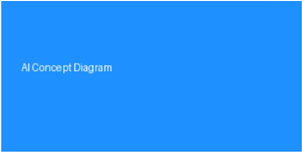

In [26]:
doc.pictures

In [27]:
print(len(doc.pictures))

1


In [28]:
from docling.chunking import HybridChunker
chunker=HybridChunker()
chunks=list(chunker.chunk(dl_doc=doc))

In [29]:
!pip install google-generativeai

In [30]:
import google.generativeai as genai

genai.configure(api_key="AQ.Ab8RN6IxJXZyVxSlOGOOtPcpdR6FtDQ1xeuGisvkrrfatTNiSQ")

model = genai.GenerativeModel("gemini-2.5-flash")

C:\Users\HP\AppData\Local\Temp\ipykernel_23520\69201668.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [31]:
def summarize_chunk(chunk):
    TEXT_PROMPT = f"""
Summarize the following chunk.
Preserve important names, numbers and facts.
Return only the summary.

Chunk:
{chunk}
"""
    return generate_response(TEXT_PROMPT)

In [32]:
IMAGE_PROMPT = """
Generate a comprehensive semantic description of this image for use in a multimodal retrieval system.

Describe all visible content including:
- Titles and headings
- Objects and entities
- Text and numbers
- Tables and charts
- Axes, legends and units
- Diagrams and flowcharts
- Relationships between components
- Colors and layout when important
- Statistics and measurements
- Technical terminology
- Key conclusions and insights

Preserve names, dates, values, and identifiers exactly.

Produce a detailed, self-contained description so that a user can answer questions about the image without directly seeing it.

Return only the description.
"""

In [33]:
def summarize_image(image):

    response = model.generate_content(
        [
            IMAGE_PROMPT,
            image
        ]
    )

    print(response.text)

    return response.text

In [34]:
documents = []
from langchain_core.documents import Document

In [35]:
from langchain_core.documents import Document

documents = []

for chunk in chunks:
    print("chunked")
    summary = summarize_chunk(str(chunk.text))

    documents.append(
        Document(
            page_content=summary,
            metadata={
                "type": "text"
            }
        )
    )

chunked
Artificial Intelligence (AI) is a computer science branch that creates machines to perform human-like tasks. There are 3 types of AI: Narrow AI, which performs specific tasks like voice assistants, General AI, which aims for human-like intelligence, and Super AI, which is a future concept that would be smarter than humans.


In [36]:
# Add images
for picture in doc.pictures:

    image = picture.get_image(doc)

    if image is None:
        continue

    summary = summarize_image(image)

    documents.append(
        Document(
            page_content=summary,
            metadata={
                "type": "image"
            }
        )
    )

The image presents a minimalist design, primarily consisting of a solid, bright blue background. Positioned in the upper-left quadrant of this blue background is a single line of white text that reads "AI Concept Diagram".

**Content Breakdown:**

*   **Background:** The dominant visual element is a uniformly colored background, rendered in a vibrant, solid blue hue. This blue occupies the entire canvas of the image.
*   **Text:**
    *   **Content:** The text displayed is "AI Concept Diagram".
    *   **Color:** The text is rendered in a stark white color, providing a strong contrast against the blue background, ensuring high readability.
    *   **Font:** The typeface appears to be a clear, sans-serif font, with no specific styling (e.g., bold, italic, underline).
    *   **Placement:** The text is horizontally left-aligned and positioned towards the top-left corner of the image, leaving significant empty space in the rest of the image.
*   **Objects and Entities:** Beyond the text a

In [37]:
len(documents)

2

In [38]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="mixedbread-ai/mxbai-embed-large-v1",
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [39]:
from langchain_chroma import Chroma

vectorstore = Chroma(
    collection_name="multimodal_rag",
    persist_directory="./chroma_mragdb",
    embedding_function=embeddings
)

In [40]:
vectorstore._collection.count()

3

In [41]:
vectorstore.add_documents(documents)

['13a22f18-5451-418f-9488-811e11f81741',
 '6c2894d6-b40b-4d33-b260-17dfe445e75f']

In [42]:
vectorstore._collection.count()

5

In [43]:
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k":20,
        "fetch_k":50
    }
)

In [44]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder(
    "BAAI/bge-reranker-large",
)

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

In [45]:
def retrieve(query, top_k=5):

    docs = retriever.invoke(query)

    pairs = [
        [query, doc.page_content]
        for doc in docs
    ]

    scores = reranker.predict(pairs)

    ranked_docs = sorted(
        zip(scores, docs),
        key=lambda x: x[0],
        reverse=True
    )

    return [
        doc
        for score, doc in ranked_docs[:top_k]
    ]

In [46]:
def build_context(query):

    retrieved_docs = retrieve(query)

    context = "\n\n".join(
        doc.page_content
        for doc in retrieved_docs
    )

    return context

In [47]:
import requests

def generate_response(prompt):

    response = requests.post(
        "https://text-generation.kuchana-akshitha.workers.dev/",
        headers={
            "Authorization": "Bearer 12345678",
            "Content-Type": "application/json"
        },
        json={
            "prompt": prompt
        }
    )

    return response.json()

In [48]:
def ask(query):

    context = build_context(query)
    print(f"The context retrived is:{context}")

    prompt = f"""
You are a helpful assistant.

Answer the question using ONLY the context below.

If the answer is not present, say:
'I could not find the answer in the provided context.'

Context:
{context}

Question:
{query}

Answer:
"""

    return generate_response(prompt)

In [49]:
answer = ask(
    "What is the problem statement give me in a single line"
)

print(answer)

The context retrived is:The image displays a minimalist design featuring a solid, vibrant blue background that uniformly fills the entire frame. Positioned in the upper-left quadrant of this blue canvas is the text "AI Concept Diagram". The text is rendered in a light color, likely white or a very pale grey, creating a strong visual contrast against the deep blue background. The blue color appears to be a bright, saturated shade, similar to a royal blue or cerulean.

Despite the text "AI Concept Diagram" suggesting the presence of a visual representation, no actual diagram, flowchart, graph, table, or any other graphical element is visible in the image. There are no axes, legends, units, statistics, or measurements. The image contains only this single line of text and the solid colored background. The layout is clean and uncluttered, focusing solely on the heading.

The image presents a minimalist design, primarily consisting of a solid, bright blue background. Positioned in the upper-

In [50]:
from transformers import AutoTokenizer
from docling.chunking import HybridChunker

tokenizer = AutoTokenizer.from_pretrained(
    "sentence-transformers/all-MiniLM-L6-v2"
)

In [51]:
chunker = HybridChunker(
    tokenizer=tokenizer,
    max_tokens=1024
)

chunks = list(chunker.chunk(dl_doc=doc))

In [52]:
len(chunks)

1

In [53]:
from langchain_text_splitters import RecursiveCharacterTextSplitter


splitter = RecursiveCharacterTextSplitter(
    chunk_size=3000,
    chunk_overlap=600
)

docs = []

for chunk in chunks:
    docs.extend(
        splitter.create_documents(
            [chunk.text]
        )
    )

In [ ]:
len(docs)

In [ ]:
docs[0]